# Spaceship Titanic — Exploratory Data Analysis

The **Spaceship Titanic** Kaggle competition asks us to predict whether a passenger
was *transported* to another dimension after the ship collided with a spacetime
anomaly. This notebook is the **exploratory** stage: we only *look* at the data to
understand its structure, missing values, and the relationships that will guide the
preprocessing and modelling steps.

> This notebook does **not** modify or save any data. Cleaning and feature
> engineering happen in `02_preprocessing.ipynb`; model training in
> `03_modeling.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load the data

Kaggle provides a pre-defined train/test split. The training set contains the
target column `Transported`; the test set does not — that is what we will predict.

In [2]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
train.head()

Train shape: (8693, 14)
Test shape:  (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 2. Data overview

A quick look at the column data types and summary statistics. The dataset mixes
**categorical** columns (`HomePlanet`, `CryoSleep`, `Destination`, `VIP`, `Cabin`)
with **numeric** columns (`Age` and the five spending columns).

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [4]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


## 3. Missing values

Almost every column has missing values — only `PassengerId` and the target
`Transported` are complete. We will need an imputation strategy for the rest
(handled in the preprocessing notebook).

In [5]:
missing = pd.DataFrame({
    "train": train.isnull().sum(),
    "test": test.reindex(columns=train.columns).isnull().sum(),
})
missing["train_%"] = (missing["train"] / len(train) * 100).round(1)
missing

,train,test,train_%
PassengerId,0,0,0.0
HomePlanet,201,87,2.3
CryoSleep,217,93,2.5
Cabin,199,100,2.3
Destination,182,92,2.1
Age,179,91,2.1
VIP,203,93,2.3
RoomService,181,82,2.1
FoodCourt,183,106,2.1
ShoppingMall,208,98,2.4


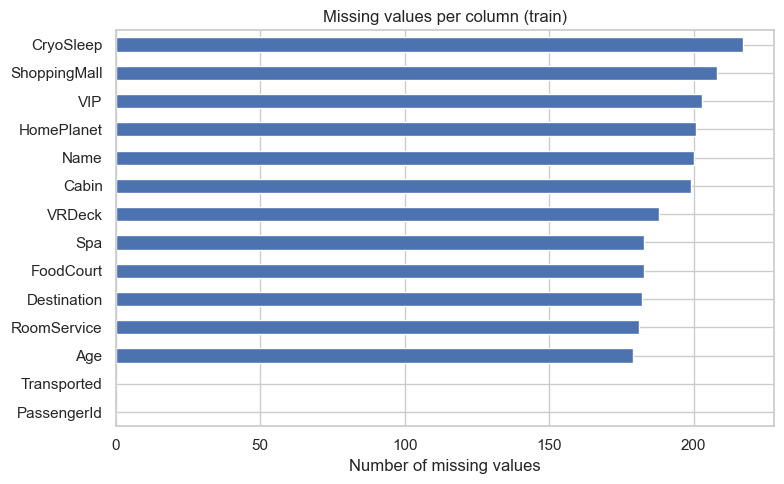

In [6]:
ax = train.isnull().sum().sort_values().plot(
    kind="barh", figsize=(8, 5), color="#4C72B0"
)
ax.set_title("Missing values per column (train)")
ax.set_xlabel("Number of missing values")
plt.tight_layout()
plt.show()

## 4. Target distribution

Before modelling we check whether the classes are balanced. An imbalanced target
would require special handling (resampling, class weights, etc.).

Transported
True     4378
False    4315
Name: count, dtype: int64

Class balance: 0.986 (1.0 = perfectly balanced)


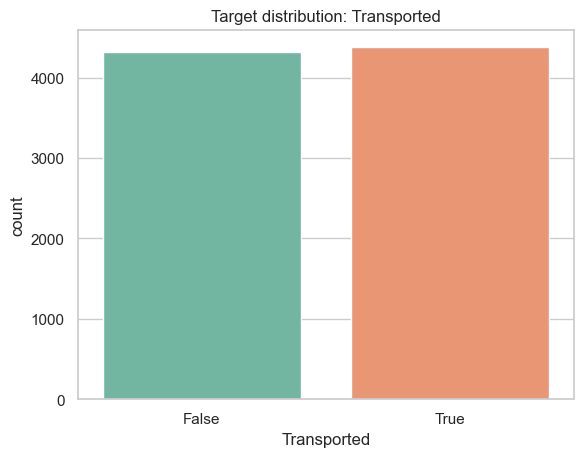

In [7]:
counts = train["Transported"].value_counts()
print(counts)
print(f"\nClass balance: {counts.min() / counts.max():.3f} (1.0 = perfectly balanced)")

ax = sns.countplot(x="Transported", hue="Transported", data=train,
                   palette="Set2", legend=False)
ax.set_title("Target distribution: Transported")
plt.show()

The two classes are almost perfectly balanced (~50/50), so accuracy is a
reasonable evaluation metric and no resampling is needed.

## 5. The `Cabin` column

`Cabin` looks like noise at first glance, but it follows the pattern
**`Deck/Number/Side`**. Splitting it exposes three potentially useful features.
We do this on a **temporary copy** here — the actual transformation lives in the
preprocessing notebook.

In [8]:
cabin_parts = train["Cabin"].str.split("/", expand=True)
cabin_parts.columns = ["Deck", "Number", "Side"]

print("Deck:\n", cabin_parts["Deck"].value_counts(), "\n")
print("Side:\n", cabin_parts["Side"].value_counts(), "\n")
print("Number — unique values:", cabin_parts["Number"].nunique())

Deck:
 Deck
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
T       5
Name: count, dtype: int64 

Side:
 Side
S    4288
P    4206
Name: count, dtype: int64 

Number — unique values: 1817


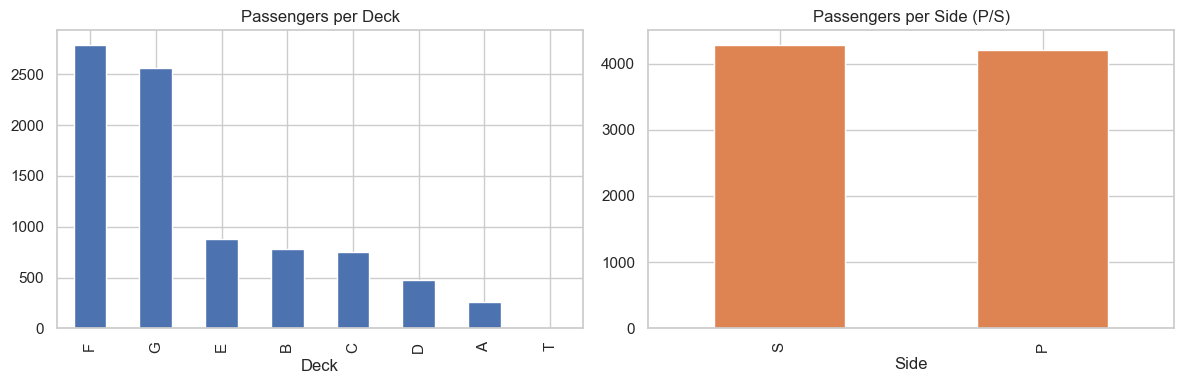

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cabin_parts["Deck"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Passengers per Deck")
cabin_parts["Side"].value_counts().plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Passengers per Side (P/S)")
plt.tight_layout()
plt.show()

`Deck` and `Side` group passengers into a handful of meaningful categories.
`Number` has hundreds of unique values and little obvious structure, so it is a
weak candidate as a feature — we will drop it during preprocessing.

## 6. Numeric features

Distributions of `Age` and the five spending columns. The spending columns are
heavily **right-skewed**: most passengers spend nothing (often because they are in
cryo-sleep), with a long tail of high spenders.

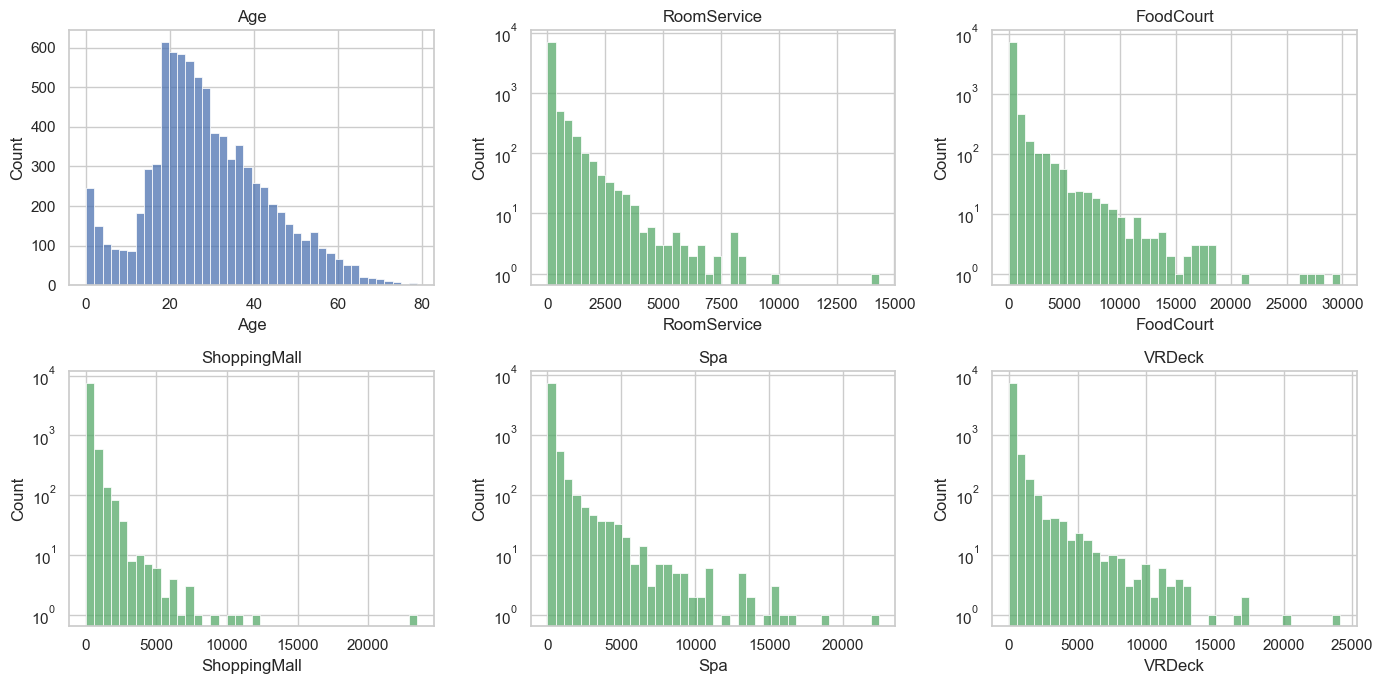

In [10]:
spending_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
sns.histplot(train["Age"].dropna(), bins=40, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Age")
for ax, col in zip(axes.flat[1:], spending_cols):
    sns.histplot(train[col].dropna(), bins=40, ax=ax, color="#55A868")
    ax.set_title(col)
    ax.set_yscale("log")  # log scale to reveal the long tail
plt.tight_layout()
plt.show()

## 7. Relationship with the target

A couple of quick cross-tabs to sanity-check which features carry signal.
`CryoSleep` stands out strongly: passengers in cryo-sleep were transported far
more often.

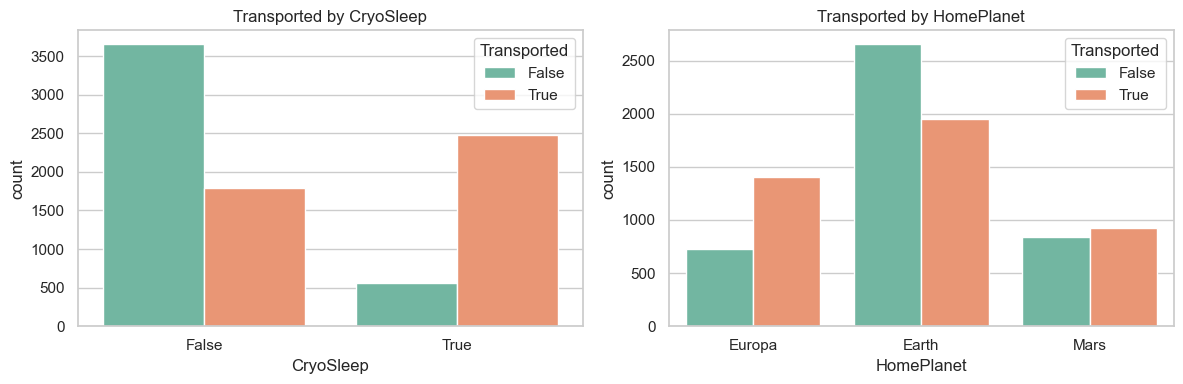

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="CryoSleep", hue="Transported", data=train, ax=axes[0], palette="Set2")
axes[0].set_title("Transported by CryoSleep")
sns.countplot(x="HomePlanet", hue="Transported", data=train, ax=axes[1], palette="Set2")
axes[1].set_title("Transported by HomePlanet")
plt.tight_layout()
plt.show()

## 8. Key takeaways

- **Missing values** appear in nearly every column and must be imputed.
- **Target is balanced** (~50/50) → accuracy is an acceptable metric.
- **`Cabin`** is worth splitting into `Deck` / `Number` / `Side`; `Number` looks
  uninformative and will be dropped.
- **Spending columns** are strongly right-skewed and tied to `CryoSleep`
  (sleeping passengers spend nothing) — useful for a smarter imputation rule.
- **`PassengerId`** and **`Name`** carry no predictive signal and will be dropped.
- **`CryoSleep`** shows a strong relationship with the target.

These observations drive the cleaning and feature-engineering decisions in
**`02_preprocessing.ipynb`**.